# Module 1 Soil Landscape Indicators
**Region:** Cache la Poudre watershed/2020 Cameron Peak Fire burn scar

Module 3 pulls soil properties and uses them immediately in the fire chain.
This module does the slower, prior thing: it maps soil *condition* on its own
terms, so that "soil health" in the SHIELD framing means something specific and
measurable before fire enters the picture.

Three products, in order:

1. **Soil exposure** how often bare ground is visible across a growing season
2. **Vegetation–soil coupling** where vegetation tracks soil condition, and where it does not
3. **Degradation screening** where exposure, declining vigour, and low organic matter coincide

None of this measures soil health directly, it scales what ground measurements tell us between
the points where those measurements exist. 

Soil layers available: ['organic_matter_pct', 'sand_fraction_pct', 'runoff_potential']
Grid: (151, 200), cell size ~30 m


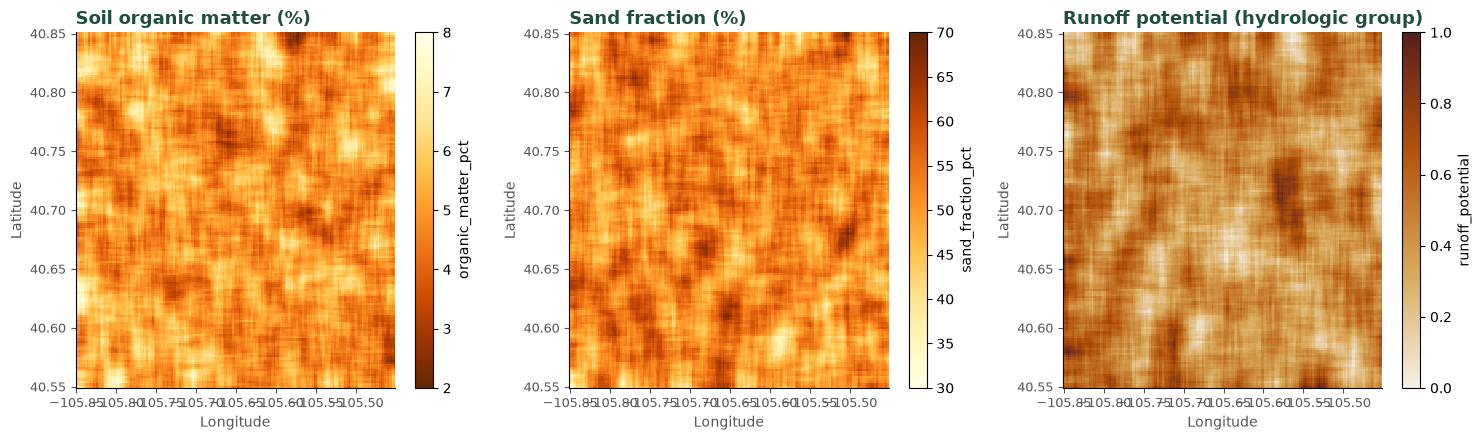

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox

# Soil properties come from SSURGO (USDA NRCS Soil Data Access), with SoilGrids
# gap-filling wherever SSURGO map units are missing or unpopulated - which in
# this AOI is most of the high-elevation Roosevelt National Forest ground, since
# SSURGO coverage thins out badly above treeline.
soil = data_access.get_soil_properties(BBOX)
terrain = data_access.get_terrain(BBOX)

print("Soil layers available:", list(soil.data_vars))
print(f"Grid: {terrain['slope_deg'].shape}, cell size ~{terrain['slope_deg'].attrs.get('cell_size_m', 30)} m")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
viz.plot_raster(soil["organic_matter_pct"], title="Soil organic matter (%)", ax=axes[0], cmap="YlOrBr_r")
viz.plot_raster(soil["sand_fraction_pct"], title="Sand fraction (%)", ax=axes[1], cmap="YlOrBr")
viz.plot_raster(soil["runoff_potential"], title="Runoff potential (hydrologic group)", ax=axes[2], cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/01_soil_inputs.png", dpi=150)
plt.show()

## Soil exposure across a growing season

A single-date NDVI minimum is the obvious way to find bare ground, and it is
the wrong one because it inherits every cloud edge, shadow, and off-nadir artefact
from whichever date happened to be lowest.

Instead: pull the full clear-sky Sentinel-2 stack for one growing season and
count the *fraction* of observations below the bare-ground threshold. A cell
bare in 8 of 10 scenes is a different management story from one bare in 1 of 10,
and only the frequency version can tell them apart.

Scene stack: FrozenMappingWarningOnValuesAccess({'time': 3, 'lat': 151, 'lon': 200})
3 scenes loaded: 2024-05-15 to 2024-09-15


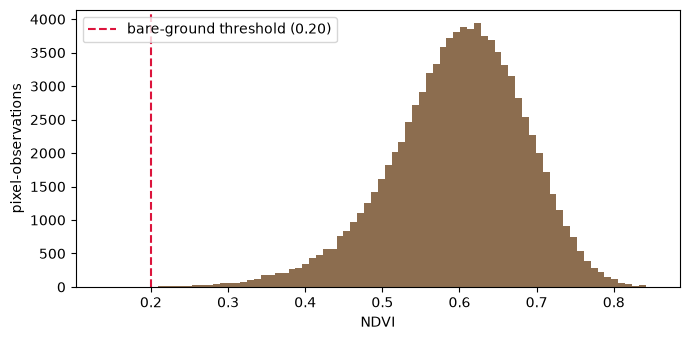

In [ ]:
# NDVI over a full season

SCENE_DATES = [
    "2024-05-15",   # green-up
    "2024-07-15",   # peak greenness
    "2024-09-15",   # senescence
]

scenes = []
for date in SCENE_DATES:
    ds = data_access.get_optical_scene(BBOX, date=date, source="sentinel-2")
    ds = ds.assign_coords(time=pd.Timestamp(date))
    scenes.append(ds)

scene_stack = xr.concat(scenes, dim="time")
print(f"Scene stack: {scene_stack.dims}")

ndvi_stack = indicators.ndvi(scene_stack)
print(f"{ndvi_stack.sizes['time']} scenes loaded: {SCENE_DATES[0]} to {SCENE_DATES[-1]}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(ndvi_stack.values[np.isfinite(ndvi_stack.values)], bins=80, color="#8c6d4f")
ax.axvline(0.20, color="crimson", ls="--", label="bare-ground threshold (0.20)")
ax.set_xlabel("NDVI"); ax.set_ylabel("pixel-observations"); ax.legend()
plt.tight_layout()
plt.savefig("../outputs/01_ndvi_histogram.png", dpi=150)
plt.show()

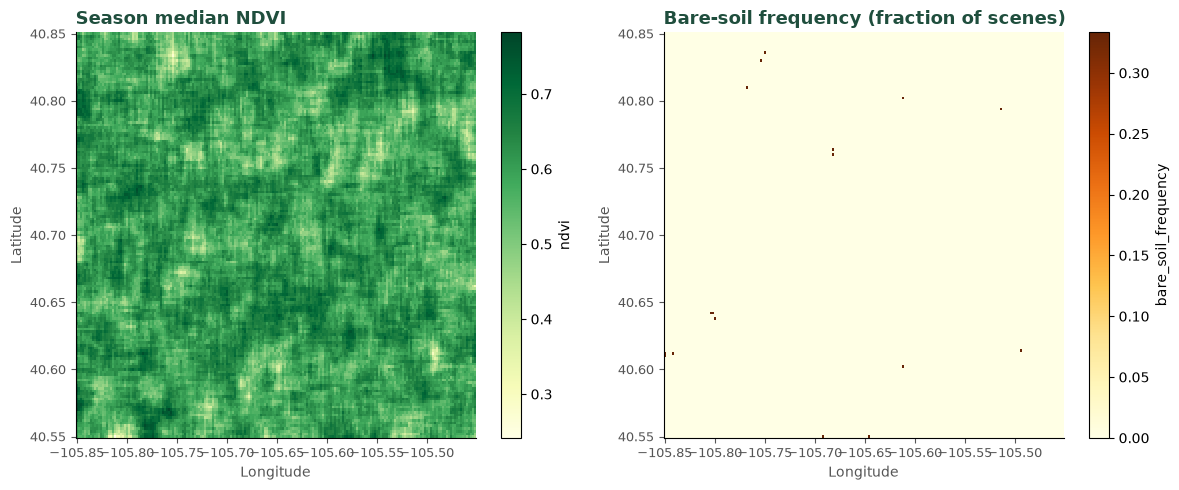

Mean bare-soil frequency:               0.00
Area persistently bare (>50% of scenes): 0.0%
Area never bare (0% of scenes):          99.9%


In [ ]:
bare_freq = indicators.bare_soil_frequency(ndvi_stack, threshold=0.20)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(ndvi_stack.median(dim="time"), title="Season median NDVI", ax=axes[0], cmap="YlGn")
viz.plot_raster(bare_freq, title="Bare-soil frequency (fraction of scenes)", ax=axes[1], cmap="YlOrBr")
plt.tight_layout()
plt.savefig("../outputs/01_soil_exposure.png", dpi=150)
plt.show()

print(f"Mean bare-soil frequency:               {float(bare_freq.mean()):.2f}")
print(f"Area persistently bare (>50% of scenes): {float((bare_freq > 0.5).mean()):.1%}")
print(f"Area never bare (0% of scenes):          {float((bare_freq == 0).mean()):.1%}")

## Vegetation–soil coupling

Where vegetation vigour tracks soil organic matter, the landscape is behaving
the way the soil map says it should. Where the two decouple, something else is
driving vegetation (aspect, grazing, irrigation, the burn scar, or an SSURGO
map unit that no longer reflects the ground truth).

Decoupled areas are the useful output here. They are where a field visit would
actually change what we know, which is the argument for pairing this with
ground sampling.

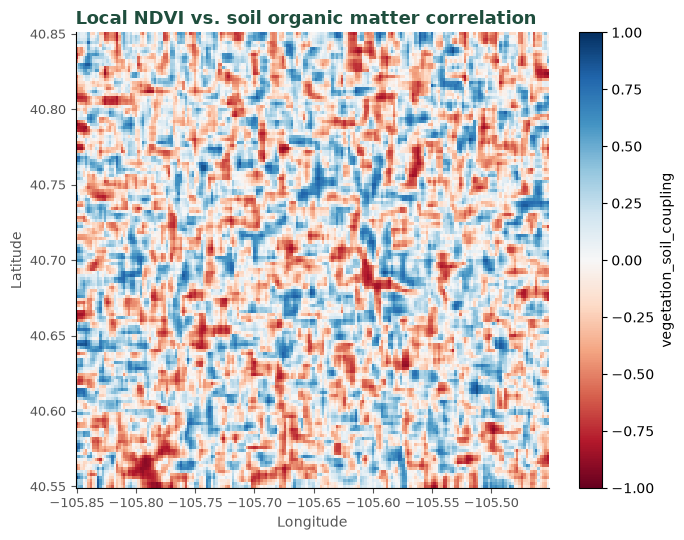

Strongly coupled area (r > 0.5):  8.9%
Decoupled area (|r| < 0.2):       37.6%
  -> these are the field-sampling priority areas: soil map and vegetation disagree


In [ ]:
# 5x5 moving window at 30 m = a 150 m neighbourhood. Large enough to average
# out per-pixel noise, small enough to stay below hillslope scale.
coupling = indicators.vegetation_soil_coupling(
    ndvi_stack.median(dim="time"),
    soil["organic_matter_pct"],
    window=5,
)

fig, ax = plt.subplots(figsize=(7, 5.5))
viz.plot_raster(coupling, title="Local NDVI vs. soil organic matter correlation", ax=ax, cmap="RdBu", vmin=-1, vmax=1)
plt.tight_layout()
plt.savefig("../outputs/01_vegetation_soil_coupling.png", dpi=150)
plt.show()

decoupled = (abs(coupling) < 0.2)
print(f"Strongly coupled area (r > 0.5):  {float((coupling > 0.5).mean()):.1%}")
print(f"Decoupled area (|r| < 0.2):       {float(decoupled.mean()):.1%}")
print("  -> these are the field-sampling priority areas: soil map and vegetation disagree")

## Degradation screening

Three signals, all required: frequently bare, losing vegetation over time, and
low in organic matter to begin with.

A bare field is a fallow field. A negative NDVI trend is a wet year followed by 
a dry one. Low organic matter is just a sandy map unit. The conjunction is what 
is worth flagging and even then this is a screening layer that says *where to look*. 

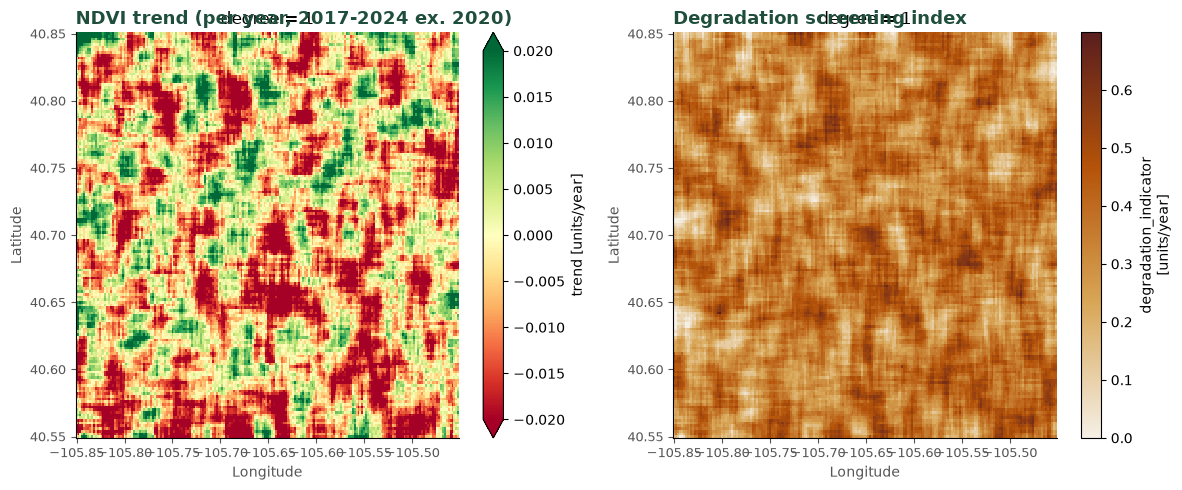

Mean degradation index:            0.347
Area flagged for review (>0.7):    0.0%


In [ ]:
annual = []
for year in range(2017, 2025):
    if year == 2020:
        continue  # Cameron Peak burned Aug-Dec 2020
    # Use a single late-summer date per year — consistent phenological window
    scene = data_access.get_optical_scene(
        BBOX,
        date=f"{year}-08-15",
        source="sentinel-2",
    )
    scene = scene.assign_coords(time=pd.Timestamp(f"{year}-08-15"))
    annual.append(indicators.ndvi(scene))

annual_stack = xr.concat(annual, dim="time")
ndvi_trend   = indicators.linear_trend(annual_stack, per_year=True)

degradation = indicators.degradation_indicator(bare_freq, ndvi_trend, soil["organic_matter_pct"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(ndvi_trend,   title="NDVI trend (per year, 2017-2024 ex. 2020)",
                ax=axes[0], cmap="RdYlGn", vmin=-0.02, vmax=0.02)
viz.plot_raster(degradation,  title="Degradation screening index",
                ax=axes[1], cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/01_degradation_indicator.png", dpi=150)
plt.show()

print(f"Mean degradation index:            {float(degradation.mean()):.3f}")
print(f"Area flagged for review (>0.7):    {float((degradation > 0.7).mean()):.1%}")

## Summarize by hydrologic soil group

Per-pixel maps are hard to act on. Agency partners work in map units and
hydrologic soil groups, so roll the indicators up into that frame this is the
table that should go into a report, not the raster.

In [ ]:
rows = []
for group in np.unique(soil["runoff_potential"].values[np.isfinite(soil["runoff_potential"].values)]):
    mask = soil["runoff_potential"] == group
    rows.append({
        "hydrologic_group": group,
        "area_pct": float(mask.mean()) * 100,
        "mean_organic_matter": float(soil["organic_matter_pct"].where(mask).mean()),
        "mean_bare_frequency": float(bare_freq.where(mask).mean()),
        "mean_ndvi_trend": float(ndvi_trend.where(mask).mean()),
        "pct_flagged": float((degradation.where(mask) > 0.7).mean()) * 100,
    })

summary = pd.DataFrame(rows).round(3)
summary.to_csv("../outputs/01_soil_group_summary.csv", index=False)
summary

,hydrologic_group,area_pct,mean_organic_matter,mean_bare_frequency,mean_ndvi_trend,pct_flagged
0,0.000,0.003,3.754,0.0,-0.008,0.0
1,0.017,0.003,3.423,0.0,0.001,0.0
2,0.030,0.003,5.108,0.0,-0.030,0.0
3,0.033,0.003,4.804,0.0,-0.031,0.0
4,0.034,0.003,5.301,0.0,-0.031,0.0
...,...,...,...,...,...,...
30166,0.949,0.003,5.175,0.0,-0.023,0.0
30167,0.950,0.003,5.817,0.0,0.015,0.0
30168,0.970,0.003,5.990,0.0,-0.006,0.0
30169,0.983,0.003,4.608,0.0,-0.012,0.0


## Summary

Soil condition mapped with exposure frequency, vegetation–soil
coupling, and a degradation screen, summarized by hydrologic soil group.

Two things carry forward. `bare_freq` and `soil` feed Module 2's transfer-weight
calculation, since bare ground is exactly what makes a hillslope hydrologically
connected. And the degradation screen gives Module 4 its pre-treatment baseline
do not claim a restoration effect without a defensible statement of what
the ground looked like first.

**What this is not:** a soil health measurement. Every layer here is an
Earth-observation proxy calibrated against SSURGO map units, which are
themselves interpolations from sparse field sampling. The value is spatial
completeness between ground points.